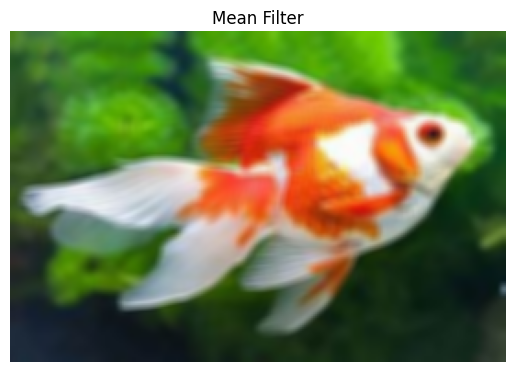

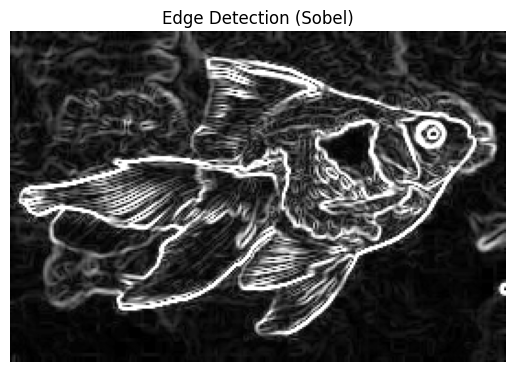

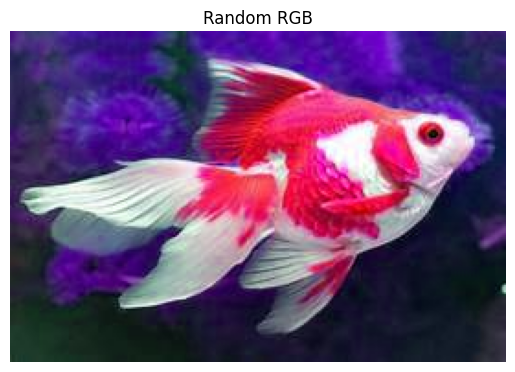

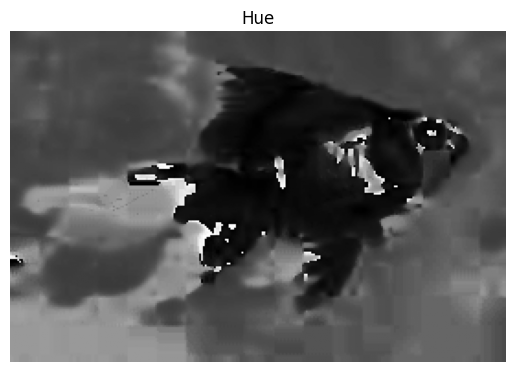

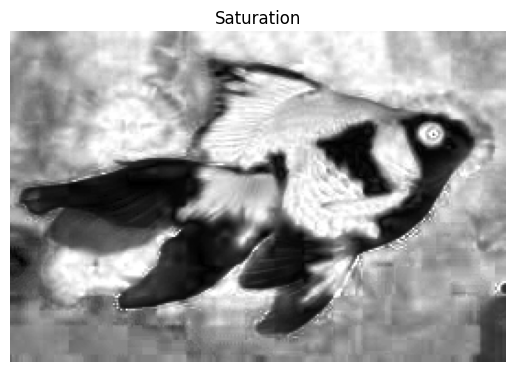

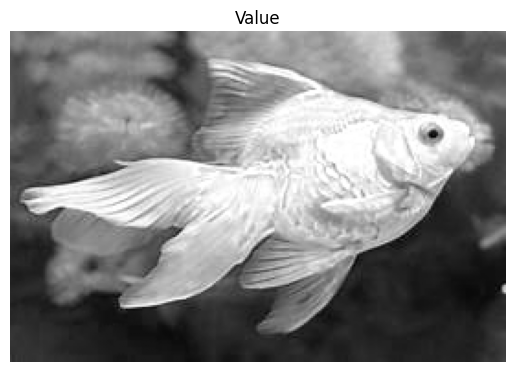

In [3]:
# THI THU THUC HANH NHAP MON XU LY ANH
# Duong dan thu muc lam viec va luu hinh
import cv2
import numpy as np
import random
import os
from matplotlib import pyplot as plt

def show_image(title, img):
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

input_dir = r"D:/nhapmonxulyanhso/nhapmonxulyanhso/DETHITHU-XLA/NM-XLA"
output_dir = os.path.join(input_dir, "luuhinh")
os.makedirs(output_dir, exist_ok=True)

# --- Câu 1 ---
a = cv2.imread(os.path.join(input_dir, "a.jpg"))

mean_filtered = cv2.blur(a, (5, 5))
cv2.imwrite(os.path.join(output_dir, "a_mean.jpg"), mean_filtered)
show_image("Mean Filter", mean_filtered)

sobel_x = cv2.Sobel(cv2.cvtColor(a, cv2.COLOR_BGR2GRAY), cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(cv2.cvtColor(a, cv2.COLOR_BGR2GRAY), cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobel_x, sobel_y)
sobel = np.uint8(np.clip(sobel, 0, 255))
cv2.imwrite(os.path.join(output_dir, "a_edge.jpg"), sobel)
show_image("Edge Detection (Sobel)", sobel)

rgb = cv2.cvtColor(a, cv2.COLOR_BGR2RGB)
perm = np.random.permutation(3)
rgb_random = rgb[:, :, perm]
cv2.imwrite(os.path.join(output_dir, "a_random_color.jpg"), cv2.cvtColor(rgb_random, cv2.COLOR_RGB2BGR))
show_image("Random RGB", rgb_random)

hsv = cv2.cvtColor(a, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
cv2.imwrite(os.path.join(output_dir, "a_hue.jpg"), h)
cv2.imwrite(os.path.join(output_dir, "a_saturation.jpg"), s)
cv2.imwrite(os.path.join(output_dir, "a_value.jpg"), v)
show_image("Hue", h)
show_image("Saturation", s)
show_image("Value", v)


Nhấn I, G, L, H, C, A để áp dụng biến đổi ảnh tương ứng


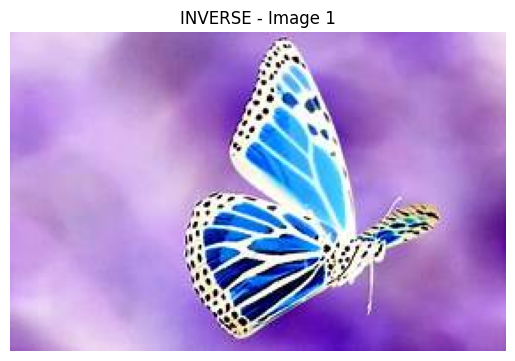

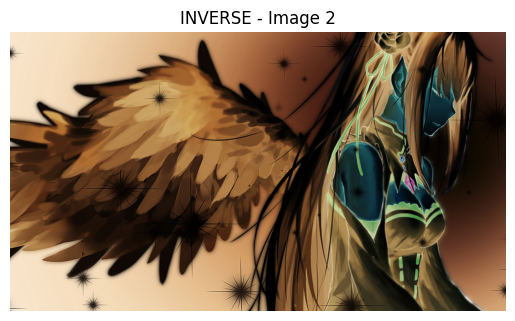

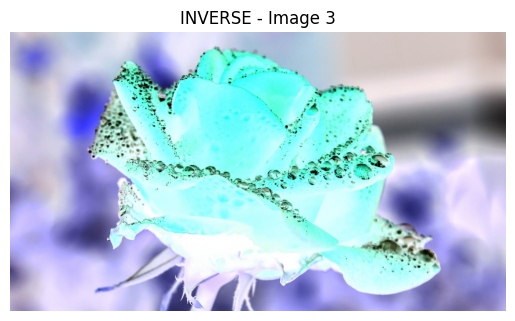

In [10]:
# --- Câu 2 ---
def inverse(img):
    return 255 - img

def gamma_correction(img, gamma):
    invGamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** invGamma * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(img, table)

def log_transform(img, c):
    img = img.astype(np.float32)
    return np.uint8(np.clip(c * np.log1p(img), 0, 255))

def contrast_stretching(img):
    min_val = random.randint(0, 100)
    max_val = random.randint(150, 255)
    return np.uint8(np.clip((img - min_val) * 255 / (max_val - min_val), 0, 255))

def equal_hist(img):
    if len(img.shape) == 3:
        img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
        img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
        return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)
    else:
        return cv2.equalizeHist(img)

def adaptive_equal_hist(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

transformations = {
    ord('I'): (inverse, "inverse"),
    ord('G'): (lambda img: gamma_correction(img, random.uniform(0.5, 2.0)), "gamma"),
    ord('L'): (lambda img: log_transform(img, random.uniform(1.0, 5.0)), "log"),
    ord('H'): (equal_hist, "hist"),
    ord('C'): (contrast_stretching, "contrast"),
    ord('A'): (adaptive_equal_hist, "adaptive")
}

images = [cv2.imread(os.path.join(input_dir, f"image{i}.jpg")) for i in range(1, 4)]
print("Nhấn I, G, L, H, C, A để áp dụng biến đổi ảnh tương ứng")
key_char = input("Nhập phím I, G, L, H, C, A để áp dụng biến đổi ảnh tương ứng: ").upper()
key = ord(key_char)


if key in transformations:
    func, name = transformations[key]
    for idx, img in enumerate(images):
        out = func(img)
        cv2.imwrite(os.path.join(output_dir, f"output_{name}_{idx+1}.jpg"), out)
        show_image(f"{name.upper()} - Image {idx+1}", out)

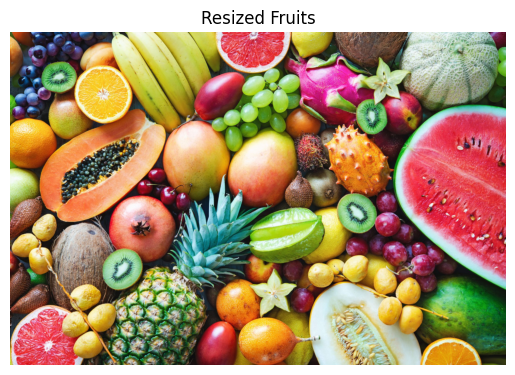

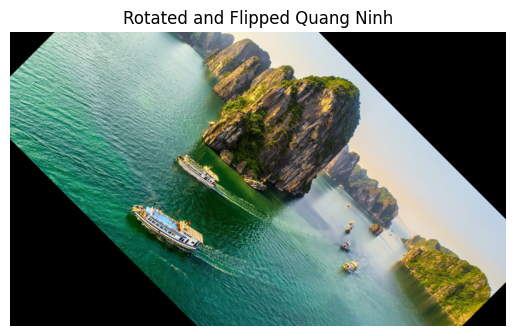

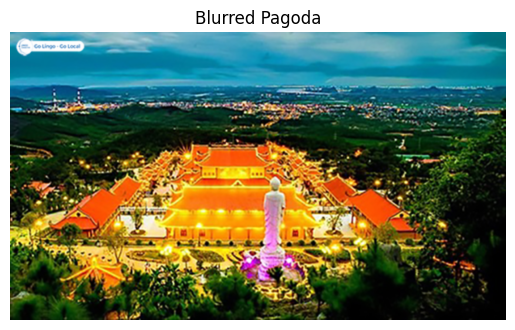

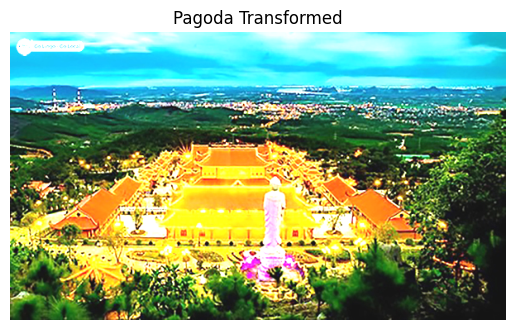

In [11]:
# --- Câu 3 ---
img1 = cv2.imread(os.path.join(input_dir, "colorful-ripe-tropical-fruits.jpg"))
h1, w1 = img1.shape[:2]
resized1 = cv2.resize(img1, (w1+30, h1+30))
cv2.imwrite(os.path.join(output_dir, "resized_fruits.jpg"), resized1)
show_image("Resized Fruits", resized1)

img2 = cv2.imread(os.path.join(input_dir, "quang_ninh.jpg"))
h2, w2 = img2.shape[:2]
M = cv2.getRotationMatrix2D((w2/2, h2/2), 45, 1)
rotated = cv2.warpAffine(img2, M, (w2, h2))
flipped = cv2.flip(rotated, 1)
cv2.imwrite(os.path.join(output_dir, "rotated_flipped_quangninh.jpg"), flipped)
show_image("Rotated and Flipped Quang Ninh", flipped)

img3 = cv2.imread(os.path.join(input_dir, "pagoda.jpg"))
resized3 = cv2.resize(img3, (0,0), fx=5, fy=5)
blurred3 = cv2.GaussianBlur(resized3, (7,7), 0)
cv2.imwrite(os.path.join(output_dir, "resized_blurred_pagoda.jpg"), blurred3)
show_image("Blurred Pagoda", blurred3)

alpha = 1.5
beta = 20
pagoda_transformed = np.clip(alpha * img3 + beta, 0, 255).astype(np.uint8)
cv2.imwrite(os.path.join(output_dir, "pagoda_transformed.jpg"), pagoda_transformed)
show_image("Pagoda Transformed", pagoda_transformed)
